# Vanguard A/B Test Analysis

## Project Overview

---
## 1. CARGAR LOS 3 DATASETS

In [54]:
import sys
!{sys.executable} -m pip install statsmodels

# Data Loading & Merging

In [55]:
import pandas as pd

demo = pd.read_csv("df_demo_clean.csv")
web_data_pt_1 = pd.read_csv("df_final_web_data_pt_1.csv")
web_data_pt_2 = pd.read_csv("df_final_web_data_pt_2.csv")
experiment_clients = pd.read_csv("df_exp_clean.csv")

print(demo.shape)
print(web_data_pt_1.shape)
print(web_data_pt_2.shape)
print(experiment_clients.shape)

(70220, 9)
(343141, 5)
(412264, 5)
(50500, 2)


client_id: Every client's unique ID.  
clnt_tenure_yr: Represents how long the client has been with Vanguard, measured in years.  
clnt_tenure_mnth: Further breaks down the client's tenure with Vanguard in months.  
clnt_age: Indicates the age of the client.  
gendr: Specifies the client's gender.  
num_accts: Denotes the number of accounts the client holds with Vanguard.  
bal: Gives the total balance spread across all accounts for a particular client.  
calls_6_mnth: Records the number of times the client reached out over a call in the past six months.  
logons_6_mnth: Reflects the frequency with which the client logged onto Vanguard's platform over the last six months.

In [56]:
demo.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6,73,60,U,2,45105.30,6,9
1,2304905,7,94,58,U,2,110860.30,6,9
2,1439522,5,64,32,U,2,52467.79,6,9
3,1562045,16,198,49,M,2,67454.65,3,6
4,5126305,12,145,33,F,2,103671.75,0,3


client_id: Every client's unique ID.  
visitor_id: A unique ID for each client-device combination.  
visit_id: A unique ID for each web visit/session.  
process_step: Marks each step in the digital process.  
date_time: Timestamp of each web activity.

In [57]:
web_data_pt_1.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [58]:
web_data_pt_2.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00
1,6019349,442094451_91531546617,154620534_35331068705_522317,confirm,2017-06-01 11:59:27
2,6019349,442094451_91531546617,154620534_35331068705_522317,step_3,2017-06-01 11:58:48
3,6019349,442094451_91531546617,154620534_35331068705_522317,step_2,2017-06-01 11:58:08
4,6019349,442094451_91531546617,154620534_35331068705_522317,step_1,2017-06-01 11:57:58


client_id: Every client's unique ID.  
variation: Indicates if a client was part of the experiment.

In [59]:
experiment_clients.head()


,client_id,variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


# Data Loading & Merging
Tienen mismas columnas asi que con concat llegaria

In [60]:
df_web_union = pd.concat([web_data_pt_1,web_data_pt_2],ignore_index= True)
print(web_data_pt_1.shape)
print(web_data_pt_2.shape)
print(df_web_union.shape)
len(df_web_union) == len(web_data_pt_1) + len(web_data_pt_2) # comprobar si concateno bien    

(343141, 5)
(412264, 5)
(755405, 5)


True

---
## 2. Exploración inicial de los datasets

> 💡 Antes de limpiar nada, necesitamos entender la estructura de los datos:  
> tipos de columnas, valores nulos, duplicados y rangos lógicos.

### 2.1 Dataset demográfico — `demo`

In [61]:
# Tipos de datos y valores nulos
demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70220 entries, 0 to 70219
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70220 non-null  int64  
 1   clnt_tenure_yr    70220 non-null  int64  
 2   clnt_tenure_mnth  70220 non-null  int64  
 3   clnt_age          70220 non-null  int64  
 4   gendr             70220 non-null  object 
 5   num_accts         70220 non-null  int64  
 6   bal               70220 non-null  float64
 7   calls_6_mnth      70220 non-null  int64  
 8   logons_6_mnth     70220 non-null  int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 4.8+ MB


# Exploratory Data Analysis

In [62]:
# Estadísticos básicos: media, mediana, desviación, min/max
demo.describe().round(2)

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,70220.00,70220.00,70220.00,70220.00,70220.00,70220.00,70220.00,70220.00
mean,5005338.30,12.07,150.86,46.34,2.26,148049.11,3.38,5.58
std,2877364.05,6.87,82.06,15.49,0.54,302191.68,2.24,2.35
min,169.00,2.00,33.00,18.00,1.00,13789.42,0.00,1.00
25%,2519283.75,6.00,82.00,33.00,2.00,37579.25,1.00,4.00
50%,5016973.50,11.00,137.00,47.00,2.00,63667.32,3.00,5.00
75%,7483780.25,16.00,192.00,59.00,2.00,138208.88,6.00,7.00
max,9999839.00,62.00,749.00,96.00,8.00,16320040.15,7.00,9.00


# Data Cleaning

In [63]:
# Conteo de valores nulos
print("Valores nulos:")
print(demo.isnull().sum())
print(f"\nDuplicados: {demo.duplicated().sum()}")

Valores nulos:
client_id           0
clnt_tenure_yr      0
clnt_tenure_mnth    0
clnt_age            0
gendr               0
num_accts           0
bal                 0
calls_6_mnth        0
logons_6_mnth       0
dtype: int64

Duplicados: 0


In [64]:
# Valores únicos columna género
# U = Unknown | M = Male | F = Female | X = valor raro | NaN = nulo
print("Valores únicos en 'gendr':")
print(demo['gendr'].value_counts(dropna=False))

Valores únicos en 'gendr':
gendr
U    23885
M    23648
F    22687
Name: count, dtype: int64


In [65]:
# Rangos de variables numéricas clave
# edad mínima 13.5 → imposible para plataforma de inversión
print(f"Edad         min: {demo['clnt_age'].min()}  max: {demo['clnt_age'].max()}")
print(f"Antigüedad   min: {demo['clnt_tenure_yr'].min()}  max: {demo['clnt_tenure_yr'].max()}")
print(f"Saldo        min: {demo['bal'].min():,.0f}  max: {demo['bal'].max():,.0f}")
print(f"Num cuentas  valores únicos: {sorted(demo['num_accts'].dropna().unique())}")

Edad         min: 18  max: 96
Antigüedad   min: 2  max: 62
Saldo        min: 13,789  max: 16,320,040
Num cuentas  valores únicos: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


### 2.2 Dataset experimento — `experiment_clients`

In [66]:
# Distribución de grupos Control/Test y NaN
print("Distribución de grupos:")
print(experiment_clients['variation'].value_counts(dropna=False))
print("\nProporción:")
print(experiment_clients['variation'].value_counts(normalize=True, dropna=False).round(3))
# ⚠️ 20.109 NaN = clientes que NO participaron en el experimento

Distribución de grupos:
variation
Test       26968
Control    23532
Name: count, dtype: int64

Proporción:
variation
Test       0.534
Control    0.466
Name: proportion, dtype: float64


Revisar duplicadoss

### 2.3 Datos web — `df_web_union`

In [67]:
print("Nulos en df_web_union:")
print(df_web_union.isnull().sum())
print(f"\nDuplicados: {df_web_union.duplicated().sum()}")

# Pasos del proceso — deben ser: start, step_1, step_2, step_3, confirm
print("\nPasos del proceso:")
print(df_web_union['process_step'].value_counts())
# Los números decrecen = hay abandono en cada paso (embudo normal)

Nulos en df_web_union:
client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

Duplicados: 10764

Pasos del proceso:
process_step
start      243945
step_1     163193
step_2     133062
step_3     112242
confirm    102963
Name: count, dtype: int64


---
## 3. Revisar duplicados

In [68]:
# Estandarizar nombres de columnas
# Convertir a minúsculas y sin espacios para evitar errores al llamar df['Columna']
demo.columns = demo.columns.str.lower().str.strip()
print("Columnas demo:", list(demo.columns))

Columnas demo: ['client_id', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr', 'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth']


In [69]:
experiment_clients.columns = experiment_clients.columns.str.lower().str.strip()
print("Columnas experiment:", list(experiment_clients.columns))

Columnas experiment: ['client_id', 'variation']


In [70]:
df_web_union.columns = df_web_union.columns.str.lower().str.strip()
print("Columnas web:", list(df_web_union.columns))

Columnas web: ['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']


In [71]:
# Revisar duplicados en cada dataset
print(f"Duplicados demo:               {demo.duplicated().sum()}")
print(f"Duplicados experiment_clients: {experiment_clients.duplicated().sum()}")
print(f"Duplicados df_web_union:       {df_web_union.duplicated().sum()}")

Duplicados demo:               0
Duplicados experiment_clients: 0
Duplicados df_web_union:       10764


In [72]:
# Eliminar duplicados en df_web_union
# Un duplicado exacto (mismo paso, mismo timestamp) es un error de registro
antes = len(df_web_union)
df_web_union.drop_duplicates(inplace=True)
print(f"Duplicados eliminados en df_web_union: {antes - len(df_web_union):,}")
print(f"Filas restantes: {len(df_web_union):,}")

Duplicados eliminados en df_web_union: 10,764
Filas restantes: 744,641


---
## 4. Limpieza de datos

>  Cada decisión de limpieza debe estar justificada:  
> explicamos qué encontramos, por qué es un problema y cómo lo resolvemos.

## Demo Dataset Cleaning

In [73]:
# Eliminar filas con nulos
# Solo hay ~14 nulos sobre 70.609 filas , eliminar no afecta al análisis
antes = len(demo)
demo.dropna(inplace=True)
print(f"Filas eliminadas por nulos: {antes - len(demo)}")
print(f"Filas restantes: {len(demo):,}")
print(f"Nulos restantes: {demo.isnull().sum().sum()}")

Filas eliminadas por nulos: 0
Filas restantes: 70,220
Nulos restantes: 0


In [74]:
# Limpiar columna 'gendr'
# El valor 'X' aparece 3 veces → reclasificamos como 'U' (Unknown)
# para no perder filas innecesariamente
print("Antes:", demo['gendr'].value_counts().to_dict())
demo['gendr'] = demo['gendr'].replace('X', 'U')
print("Después:", demo['gendr'].value_counts().to_dict())

Antes: {'U': 23885, 'M': 23648, 'F': 22687}
Después: {'U': 23885, 'M': 23648, 'F': 22687}


In [75]:
# Eliminar clientes menores de 18 años
#  Vanguard gestiona inversiones no puede haber menores de edad
# Estos registros son errores de entrada de datos
menores = demo[demo['clnt_age'] < 18]
print(f"Clientes con edad < 18: {len(menores)}")

antes = len(demo)
demo = demo[demo['clnt_age'] >= 18].copy()
print(f"Filas eliminadas: {antes - len(demo)}")
print(f"Filas restantes: {len(demo):,}")

Clientes con edad < 18: 0
Filas eliminadas: 0
Filas restantes: 70,220


In [76]:
# Convertir columnas float → int
# pandas las guarda como float cuando hay nulos (que ya eliminamos)
# Nadie tiene 36.0 años → convertimos a int para mayor claridad
cols_int = ['clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age',
            'num_accts', 'calls_6_mnth', 'logons_6_mnth']

for col in cols_int:
    demo[col] = demo[col].astype(int)

print("Tipos de datos tras limpieza:")
print(demo.dtypes)

Tipos de datos tras limpieza:
client_id             int64
clnt_tenure_yr        int64
clnt_tenure_mnth      int64
clnt_age              int64
gendr                object
num_accts             int64
bal                 float64
calls_6_mnth          int64
logons_6_mnth         int64
dtype: object


In [77]:
# Verificación final demo
print(f"Shape final demo: {demo.shape}")
print(f"Nulos: {demo.isnull().sum().sum()}")
demo.describe().round(2)

Shape final demo: (70220, 9)
Nulos: 0


,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,70220.00,70220.00,70220.00,70220.00,70220.00,70220.00,70220.00,70220.00
mean,5005338.30,12.07,150.86,46.34,2.26,148049.11,3.38,5.58
std,2877364.05,6.87,82.06,15.49,0.54,302191.68,2.24,2.35
min,169.00,2.00,33.00,18.00,1.00,13789.42,0.00,1.00
25%,2519283.75,6.00,82.00,33.00,2.00,37579.25,1.00,4.00
50%,5016973.50,11.00,137.00,47.00,2.00,63667.32,3.00,5.00
75%,7483780.25,16.00,192.00,59.00,2.00,138208.88,6.00,7.00
max,9999839.00,62.00,749.00,96.00,8.00,16320040.15,7.00,9.00


## Experiment Dataset Cleaning

In [78]:
# Filtrar solo participantes del experimento (eliminar NaN en variation)
# Los 20.109 NaN son clientes que NO participaron en el A/B test
print("Antes:")
print(experiment_clients['variation'].value_counts(dropna=False))

experiment_clients = experiment_clients.dropna(subset=['variation']).copy()

print("\nDespués (solo participantes):")
print(experiment_clients['variation'].value_counts())
print("\nProporción:")
print(experiment_clients['variation'].value_counts(normalize=True).round(3))

Antes:
variation
Test       26968
Control    23532
Name: count, dtype: int64

Después (solo participantes):
variation
Test       26968
Control    23532
Name: count, dtype: int64

Proporción:
variation
Test       0.534
Control    0.466
Name: proportion, dtype: float64


## Web Dataset Cleaning

In [79]:
# Convertir date_time a tipo datetime
# Necesario para calcular tiempos entre pasos y ordenar eventos
df_web_union['date_time'] = pd.to_datetime(df_web_union['date_time'])

print("Rango de fechas:")
print(f"  Inicio: {df_web_union['date_time'].min()}")
print(f"  Fin:    {df_web_union['date_time'].max()}")
print("  (Experimento oficial: 15/03/2017 – 20/06/2017 ✅)")

Rango de fechas:
  Inicio: 2017-03-15 00:03:03
  Fin:    2017-06-20 23:59:57
  (Experimento oficial: 15/03/2017 – 20/06/2017 ✅)


In [80]:
# Verificación final df_web_union
print(f"Shape final df_web_union: {df_web_union.shape}")
print(f"Nulos: {df_web_union.isnull().sum().sum()}")
df_web_union.dtypes

Shape final df_web_union: (744641, 5)
Nulos: 0


client_id                int64
visitor_id              object
visit_id                object
process_step            object
date_time       datetime64[ns]
dtype: object

---
## 5. Unión de los datasets

> Unimos los 3 datasets usando `client_id` como clave común.  
> **inner join**: solo filas que existen en AMBAS tablas.  
> **left join**: todas las filas de la izquierda aunque no haya coincidencia.

In [81]:
# Merge 1: web + experimento
# inner join → solo clientes que visitaron la web Y participaron en el A/B test
df_merged = df_web_union.merge(experiment_clients, on='client_id', how='inner')
print(f"Web ({len(df_web_union):,}) + Experiment ({len(experiment_clients):,}) → {len(df_merged):,} filas")

Web (744,641) + Experiment (50,500) → 317,235 filas


In [82]:
# Merge 2: añadir datos demográficos
# left join → conservamos todas las sesiones web aunque falte la demografía
df_final = df_merged.merge(demo, on='client_id', how='left')
print(f"Dataset final: {df_final.shape}")
df_final.head()

Dataset final: (317235, 14)


,client_id,visitor_id,visit_id,process_step,date_time,variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0


In [83]:
# Confirmar distribución de grupos en el dataset final
print("Control vs Test en dataset final:")
print(df_final['variation'].value_counts())
print()
print(df_final['variation'].value_counts(normalize=True).round(3))

Control vs Test en dataset final:
variation
Test       176699
Control    140536
Name: count, dtype: int64

variation
Test       0.557
Control    0.443
Name: proportion, dtype: float64


# KPI Analysis

# KPI Analysis

---
## 6. Crear columna `completion_flag`

>  Marca con 1 los clientes que llegaron a `confirm` (completaron el proceso)  
> y con 0 los que no. Clave para calcular la **Completion Rate** en el Día 3.

## Completion Rate

In [138]:
# KPI 1 — Completion Rate correcto
# Fórmula: clientes únicos que llegan a confirm / clientes únicos que hacen start

completion_table = (
    df_final
    .groupby(['variation', 'process_step'])['client_id']
    .nunique()
    .unstack()
)

completion_table['completion_rate'] = (
    completion_table['confirm'] / completion_table['start']
)

completion_table = completion_table[['start', 'confirm', 'completion_rate']]

completion_table

process_step,start,confirm,completion_rate
variation,,,
Control,23397,15434,0.659657
Test,26679,18687,0.700439


## Completion Rate

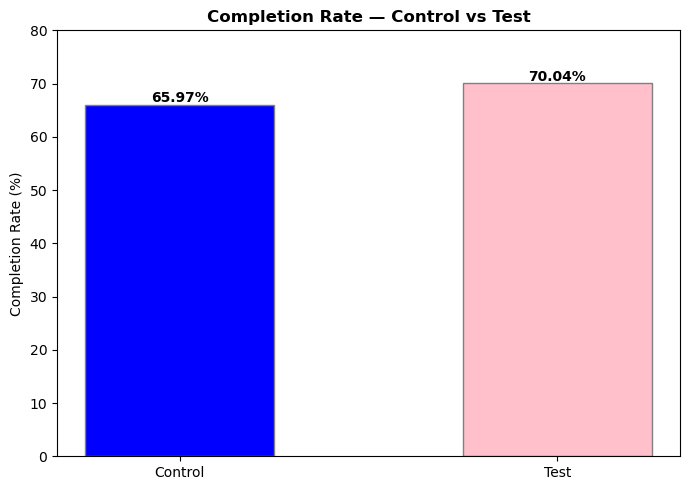

In [85]:
import matplotlib.pyplot as plt

cr = completion_table['completion_rate']

colores = {'Control': 'blue', 'Test': 'pink'}

plt.figure(figsize=(7, 5))

bars = plt.bar(
    cr.index,
    cr.values * 100,
    color=[colores[v] for v in cr.index],
    width=0.5,
    edgecolor='gray'
)

for bar, val in zip(bars, cr.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val*100:.2f}%',
        ha='center',
        fontweight='bold'
    )

plt.title('Completion Rate — Control vs Test', fontweight='bold')
plt.ylabel('Completion Rate (%)')
plt.ylim(0, 80)
plt.tight_layout()
plt.show()

In [139]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

# Test de proporciones
# H0: Completion Rate Test <= Completion Rate Control
# H1: Completion Rate Test > Completion Rate Control

successes = np.array([
    completion_table.loc['Test', 'confirm'],
    completion_table.loc['Control', 'confirm']
])

nobs = np.array([
    completion_table.loc['Test', 'start'],
    completion_table.loc['Control', 'start']
])

z_stat, p_value = proportions_ztest(
    count=successes,
    nobs=nobs,
    alternative='larger'
)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Test has a significantly higher Completion Rate than Control.")
else:
    print("Fail to reject H0: there is not enough evidence that Test is better than Control.")

Z-statistic: 9.771961363899493
P-value: 7.427399236692051e-23
Reject H0: Test has a significantly higher Completion Rate than Control.


---
## 7. EDA — ¿Quiénes son los clientes de Vanguard?

>  **Análisis univariante**: estudiamos cada variable individualmente.  
> Numéricas continuas → histograma + boxplot.  
> Categóricas → barplot + pie chart.  
> Numéricas discretas → countplot.

# Exploratory Data Analysis

## Client Age

In [86]:
print("=== Estadísticos de edad ===")
print(f"Media:    {demo['clnt_age'].mean():.1f} años")
print(f"Mediana:  {demo['clnt_age'].median():.0f} años")
print(f"Moda:     {demo['clnt_age'].mode()[0]} años")
print(f"Std:      {demo['clnt_age'].std():.1f}")
print(f"Skewness: {demo['clnt_age'].skew():.3f}  (>0 = cola derecha)")
print(f"Kurtosis: {demo['clnt_age'].kurtosis():.3f}")

=== Estadísticos de edad ===
Media:    46.3 años
Mediana:  47 años
Moda:     57 años
Std:      15.5
Skewness: 0.093  (>0 = cola derecha)
Kurtosis: -0.931


In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

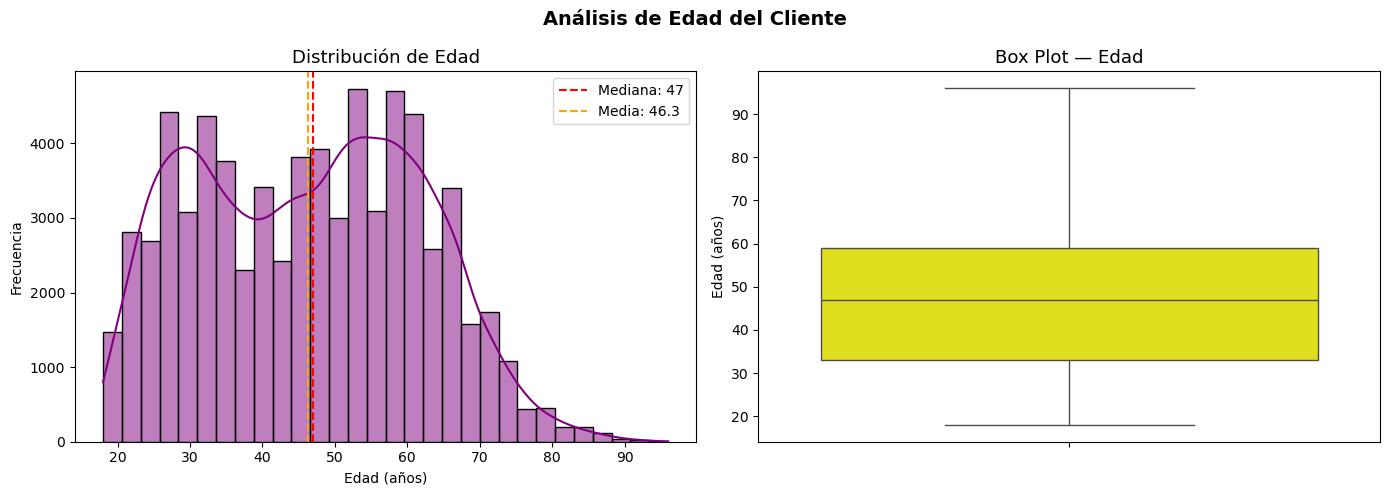

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(demo['clnt_age'], kde=True, bins=30, color='purple', ax=axes[0])
axes[0].axvline(demo['clnt_age'].median(), color='red', linestyle='--',
                label=f'Mediana: {demo["clnt_age"].median():.0f}')
axes[0].axvline(demo['clnt_age'].mean(), color='orange', linestyle='--',
                label=f'Media: {demo["clnt_age"].mean():.1f}')
axes[0].set_title('Distribución de Edad', fontsize=13)
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

sns.boxplot(y=demo['clnt_age'], color='yellow', ax=axes[1])
axes[1].set_title('Box Plot — Edad', fontsize=13)
axes[1].set_ylabel('Edad (años)')

plt.suptitle('Análisis de Edad del Cliente', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Client Tenure

In [89]:
print("=== Estadísticos de antigüedad ===")
print(demo['clnt_tenure_yr'].describe().round(2))
print(f"Skewness: {demo['clnt_tenure_yr'].skew():.3f}")

=== Estadísticos de antigüedad ===
count    70220.00
mean        12.07
std          6.87
min          2.00
25%          6.00
50%         11.00
75%         16.00
max         62.00
Name: clnt_tenure_yr, dtype: float64
Skewness: 1.038


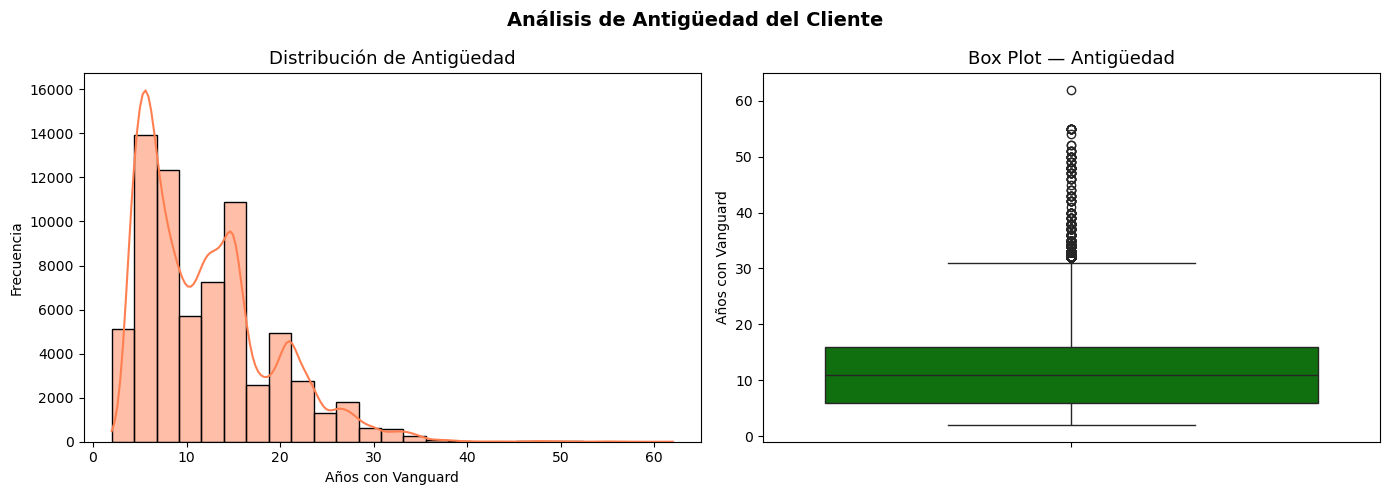

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(demo['clnt_tenure_yr'], kde=True, bins=25, color='coral', ax=axes[0])
axes[0].set_title('Distribución de Antigüedad', fontsize=13)
axes[0].set_xlabel('Años con Vanguard')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(y=demo['clnt_tenure_yr'], color='green', ax=axes[1])
axes[1].set_title('Box Plot — Antigüedad', fontsize=13)
axes[1].set_ylabel('Años con Vanguard')

plt.suptitle('Análisis de Antigüedad del Cliente', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.3 Género

In [91]:
gendr_counts = demo['gendr'].value_counts()
gendr_pct    = demo['gendr'].value_counts(normalize=True).round(3)
print(pd.concat([gendr_counts, gendr_pct], axis=1, keys=['Count', 'Proporción']))

       Count  Proporción
gendr                   
U      23885       0.340
M      23648       0.337
F      22687       0.323


/var/folders/6v/r5sx7xq16f98zxc16kcn3w8r0000gn/T/ipykernel_36611/593872665.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gendr_counts.index, y=gendr_counts.values,


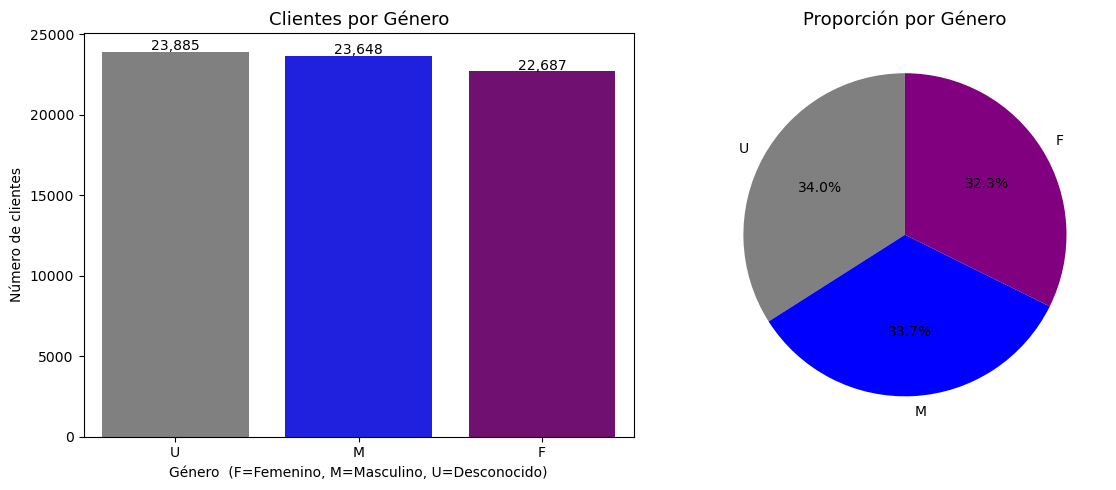

In [92]:
colores = {'F': 'purple', 'M': 'blue', 'U': 'gray'}
orden = gendr_counts.index.tolist()
lista_colores = [colores[g] for g in orden]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=gendr_counts.index, y=gendr_counts.values,
            palette=lista_colores, ax=axes[0])
axes[0].set_title('Clientes por Género', fontsize=13)
axes[0].set_xlabel('Género  (F=Femenino, M=Masculino, U=Desconocido)')
axes[0].set_ylabel('Número de clientes')
for i, v in enumerate(gendr_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(gendr_counts.values, labels=gendr_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=lista_colores)
axes[1].set_title('Proporción por Género', fontsize=13)

plt.tight_layout()
plt.show()

### 7.4 Número de cuentas y saldo

/var/folders/6v/r5sx7xq16f98zxc16kcn3w8r0000gn/T/ipykernel_36611/2609858253.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='num_accts', data=demo, order=order,


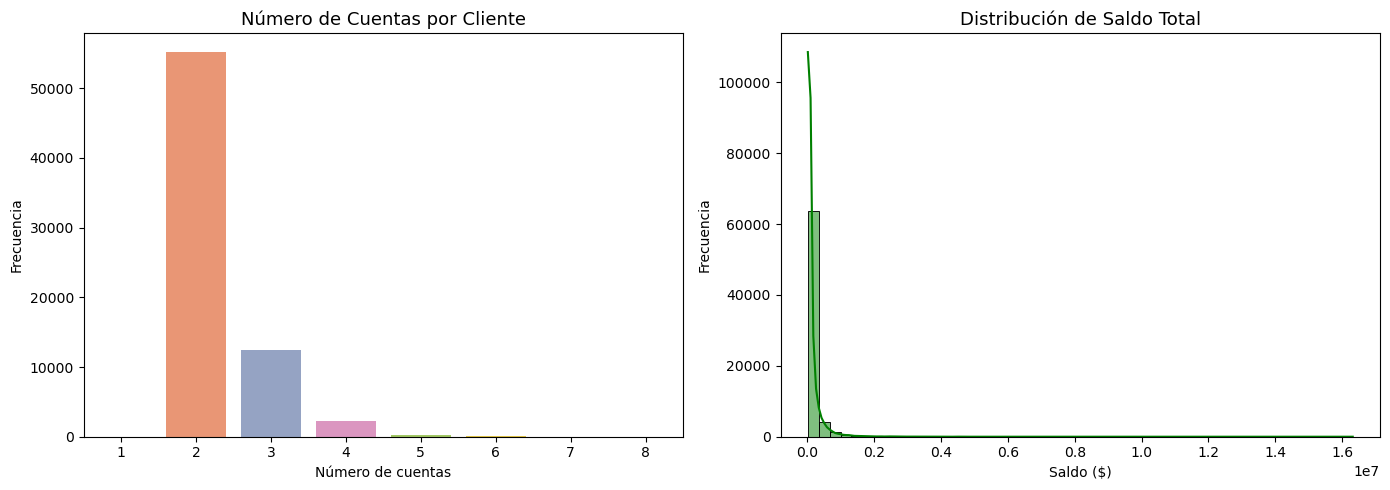

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = sorted(demo['num_accts'].unique())
sns.countplot(x='num_accts', data=demo, order=order,
              palette='Set2', ax=axes[0])
axes[0].set_title('Número de Cuentas por Cliente', fontsize=13)
axes[0].set_xlabel('Número de cuentas')
axes[0].set_ylabel('Frecuencia')

sns.histplot(demo['bal'], kde=True, bins=50,
             color='green', ax=axes[1])
axes[1].set_title('Distribución de Saldo Total', fontsize=13)
axes[1].set_xlabel('Saldo ($)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### 7.5 Comportamiento digital — Llamadas y Logons

In [94]:
for col, nombre in [('calls_6_mnth', 'Llamadas 6m'), ('logons_6_mnth', 'Logons 6m')]:
    print(f"{nombre} → media: {demo[col].mean():.1f}  mediana: {demo[col].median():.0f}  max: {demo[col].max()}")

Llamadas 6m → media: 3.4  mediana: 3  max: 7
Logons 6m → media: 5.6  mediana: 5  max: 9


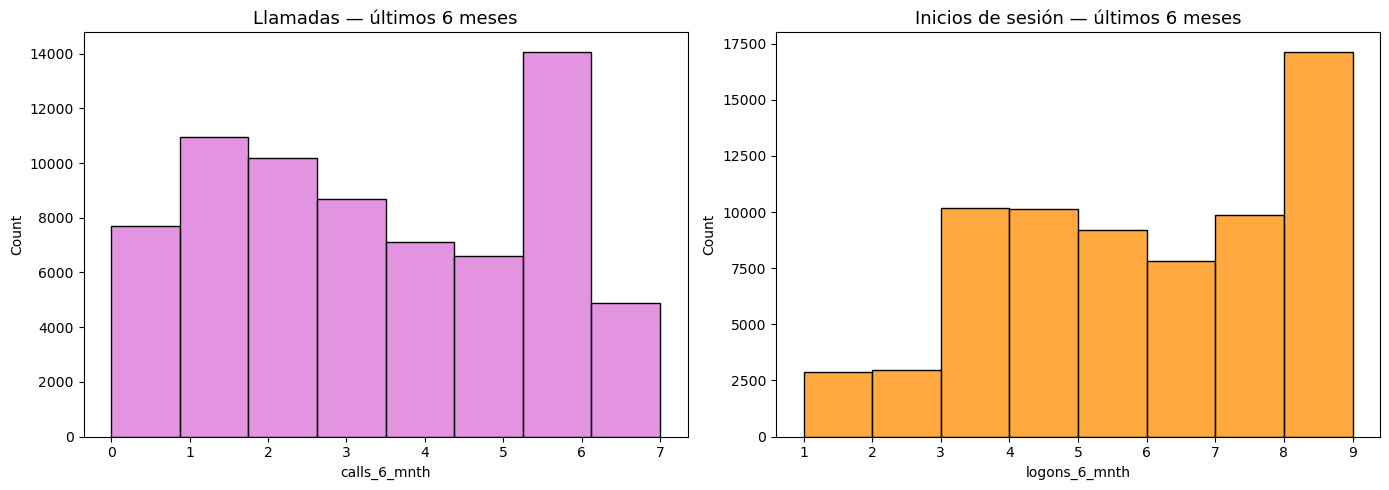

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, titulo, color in zip(axes,
    ['calls_6_mnth', 'logons_6_mnth'],
    ['Llamadas — últimos 6 meses', 'Inicios de sesión — últimos 6 meses'],
    ['orchid', 'darkorange']):
    sns.histplot(demo[col], bins=8, color=color, ax=ax)
    ax.set_title(titulo, fontsize=13)

plt.tight_layout()
plt.show()

---
## 8. Embudo de conversión (Funnel)

>  En cada paso del proceso algunos usuarios abandonan.  
> Visualizamos cuántos llegan a cada paso para ver dónde hay más abandono.

In [96]:
orden_pasos = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

funnel = (df_final.groupby(['variation', 'process_step'])['client_id']
          .nunique().reset_index().rename(columns={'client_id': 'clientes_unicos'}))

funnel['process_step'] = pd.Categorical(funnel['process_step'], categories=orden_pasos, ordered=True)
funnel = funnel.sort_values(['variation', 'process_step'])
print(funnel)

  variation process_step  clientes_unicos
1   Control        start            23397
2   Control       step_1            20152
3   Control       step_2            18650
4   Control       step_3            17422
0   Control      confirm            15434
6      Test        start            26679
7      Test       step_1            24267
8      Test       step_2            22258
9      Test       step_3            20881
5      Test      confirm            18687


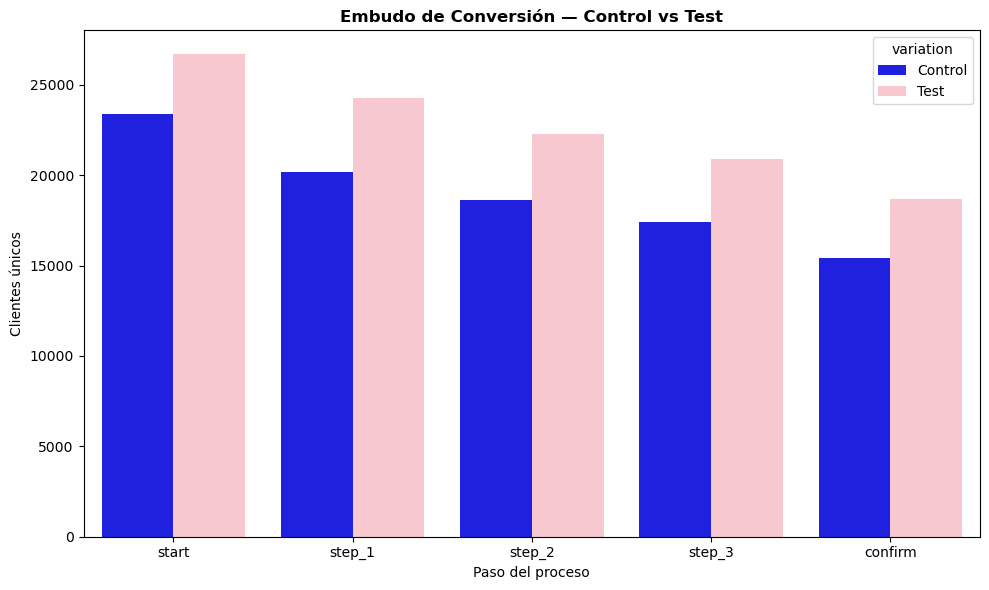

In [97]:
plt.figure(figsize=(10, 6))
sns.barplot(x='process_step', y='clientes_unicos', hue='variation',
            data=funnel, palette={'Control': 'blue', 'Test': 'pink'}, order=orden_pasos)
plt.title('Embudo de Conversión — Control vs Test', fontweight='bold')
plt.xlabel('Paso del proceso')
plt.ylabel('Clientes únicos')
plt.tight_layout()
plt.show()

- El mayor abandono ocurre en el paso **start → step_1** en ambos grupos.


---
## 9. Comparativa demográfica Control vs. Test

> Para que el experimento sea válido, los grupos deben ser similares en demografía.  
> Si el grupo Test fuera más joven o más rico, las diferencias podrían deberse  
> a eso y no a la nueva UI. Esto se llama verificar la comparabilidad de los grupos.

In [98]:
demo_exp = demo.merge(experiment_clients, on='client_id', how='inner')

stats = demo_exp.groupby('variation')[['clnt_age', 'clnt_tenure_yr', 'bal', 'num_accts']].agg(['mean', 'median'])
print(stats.round(2))

          clnt_age        clnt_tenure_yr               bal            \
              mean median           mean median       mean    median   
variation                                                              
Control      47.29   48.0          12.09   11.0  150286.21  66119.51   
Test         46.92   47.0          11.99   11.0  149103.15  65524.19   

          num_accts         
               mean median  
variation                   
Control        2.26    2.0  
Test           2.25    2.0  


/var/folders/6v/r5sx7xq16f98zxc16kcn3w8r0000gn/T/ipykernel_36611/936257588.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='variation', y=col, data=demo_exp, palette=palette, ax=ax)
/var/folders/6v/r5sx7xq16f98zxc16kcn3w8r0000gn/T/ipykernel_36611/936257588.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='variation', y=col, data=demo_exp, palette=palette, ax=ax)


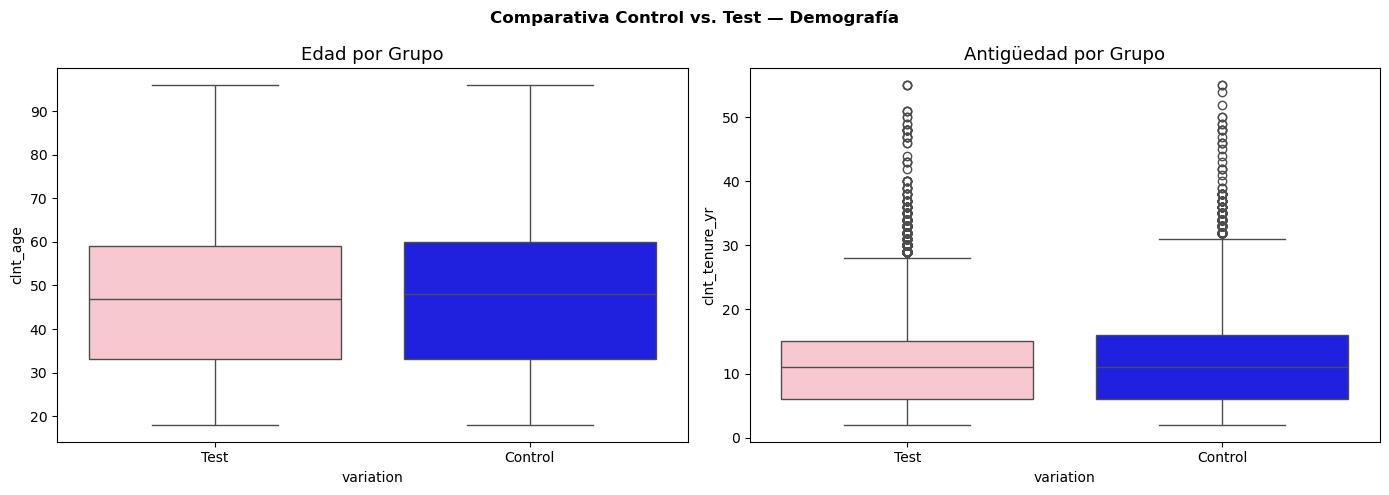

In [99]:
palette = {'Control': 'blue', 'Test': 'pink'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, titulo in zip(axes, ['clnt_age', 'clnt_tenure_yr'], ['Edad por Grupo', 'Antigüedad por Grupo']):
    sns.boxplot(x='variation', y=col, data=demo_exp, palette=palette, ax=ax)
    ax.set_title(titulo, fontsize=13)

plt.suptitle('Comparativa Control vs. Test — Demografía', fontweight='bold')
plt.tight_layout()
plt.show()

# GUARDAMOS

In [100]:
demo.to_csv('df_demo_clean.csv', index=False)
experiment_clients.to_csv('df_exp_clean.csv', index=False)
df_web_union.to_csv('df_web_clean.csv', index=False)
df_final.to_csv('df_final.csv', index=False)

print("Archivos guardados ✅")
print("  df_demo_clean.csv")
print("  df_exp_clean.csv")
print("  df_web_clean.csv")
print("  df_final.csv")

Archivos guardados ✅
  df_demo_clean.csv
  df_exp_clean.csv
  df_web_clean.csv
  df_final.csv


---
## 0. Imports y carga de datos limpios

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)

In [102]:
# Cargamos los datos limpios generados en el Día 1-2
demo               = pd.read_csv('df_demo_clean.csv')
experiment_clients = pd.read_csv('df_exp_clean.csv')
df_web_union       = pd.read_csv('df_web_clean.csv')
df_final           = pd.read_csv('df_final.csv')

# Aseguramos que date_time es datetime
df_web_union['date_time'] = pd.to_datetime(df_web_union['date_time'])
df_final['date_time']     = pd.to_datetime(df_final['date_time'])

# Orden lógico de los pasos del proceso
ORDEN_PASOS = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

print('Datos cargados ✅')
print(f'df_final shape: {df_final.shape}')

Datos cargados ✅
df_final shape: (317235, 14)


---
## 1. KPI 1 — Completion Rate (Tasa de Finalización)
  
> El porcentaje de clientes que inician el proceso (`start`) y llegan hasta el final (`confirm`).  
> Es el KPI más importante del experimento.
>
> **Fórmula:**  
> `CR = clientes que llegan a confirm / clientes que hacen start`

## Completion Rate

In [103]:
# Clientes que completaron el proceso (llegaron a confirm)
clientes_confirm = df_final[df_final['process_step'] == 'confirm']['client_id'].unique()
df_final['completion_flag'] = df_final['client_id'].isin(clientes_confirm).astype(int)

# Completion Rate por grupo (solo contamos desde start)
cr = (df_final[df_final['process_step'] == 'start']
      .groupby('variation')['completion_flag']
      .mean()
      .round(4))

print('=== Completion Rate por grupo ===')
print(cr)
print(f'\nDiferencia (Test - Control): {(cr["Test"] - cr["Control"]):.4f}')
print(f'Mejora relativa: {((cr["Test"] - cr["Control"]) / cr["Control"] * 100):.2f}%')

=== Completion Rate por grupo ===
variation
Control    0.6211
Test       0.6195
Name: completion_flag, dtype: float64

Diferencia (Test - Control): -0.0016
Mejora relativa: -0.26%


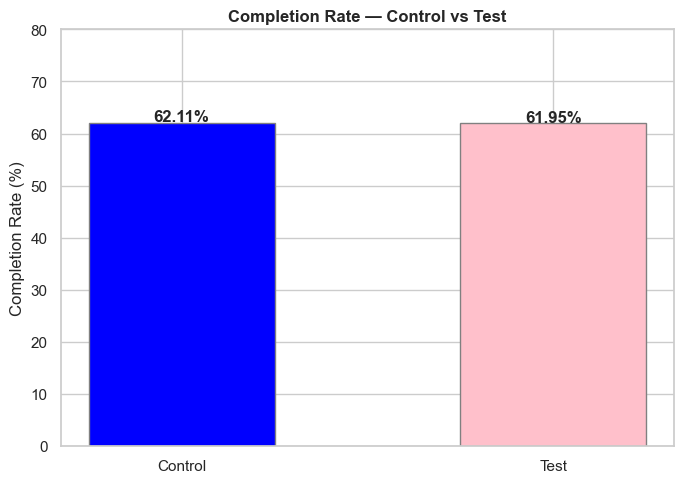

In [104]:
colores = {'Control': 'blue', 'Test': 'pink'}

plt.figure(figsize=(7, 5))
bars = plt.bar(cr.index, cr.values * 100,
               color=[colores[v] for v in cr.index], width=0.5, edgecolor='gray')

for bar, val in zip(bars, cr.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val*100:.2f}%', ha='center', fontweight='bold')

plt.title('Completion Rate — Control vs Test', fontweight='bold')
plt.ylabel('Completion Rate (%)')
plt.ylim(0, 80)
plt.tight_layout()
plt.show()

- La diferencia es mínima (-0.16 pp). La nueva UI **no mejora** significativamente la tasa de finalización. Habrá que confirmarlo con una prueba de hipótesis (Día 4-5).

In [137]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

# Test de proporciones
# H0: Completion Rate Test <= Completion Rate Control
# H1: Completion Rate Test > Completion Rate Control

successes = np.array([
    completion_table.loc['Test', 'confirm'],
    completion_table.loc['Control', 'confirm']
])

nobs = np.array([
    completion_table.loc['Test', 'start'],
    completion_table.loc['Control', 'start']
])

z_stat, p_value = proportions_ztest(
    count=successes,
    nobs=nobs,
    alternative='larger'
)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Test has a significantly higher Completion Rate than Control.")
else:
    print("Fail to reject H0: there is not enough evidence that Test is better than Control.")

Z-statistic: 9.771961363899493
P-value: 7.427399236692051e-23
Reject H0: Test has a significantly higher Completion Rate than Control.


---
## 2. KPI 2 — Drop-off por paso (Embudo de conversión)

> El porcentaje de clientes que abandona el proceso en cada paso.  
> Nos dice dónde hay más fricción en el proceso.
>
> **Fórmula:**  
> `Drop-off paso i = 1 - (clientes paso i+1 / clientes paso i)`

In [105]:
funnel = (df_final.groupby(['variation', 'process_step'])['client_id']
          .nunique().reset_index().rename(columns={'client_id': 'clientes'}))

funnel['process_step'] = pd.Categorical(funnel['process_step'], categories=ORDEN_PASOS, ordered=True)
funnel = funnel.sort_values(['variation', 'process_step'])
funnel['drop_off'] = funnel.groupby('variation')['clientes'].transform(lambda x: (1 - x / x.shift(1)).round(4))

print(funnel.to_string(index=False))

variation process_step  clientes  drop_off
  Control        start     23397       NaN
  Control       step_1     20152    0.1387
  Control       step_2     18650    0.0745
  Control       step_3     17422    0.0658
  Control      confirm     15434    0.1141
     Test        start     26679       NaN
     Test       step_1     24267    0.0904
     Test       step_2     22258    0.0828
     Test       step_3     20881    0.0619
     Test      confirm     18687    0.1051


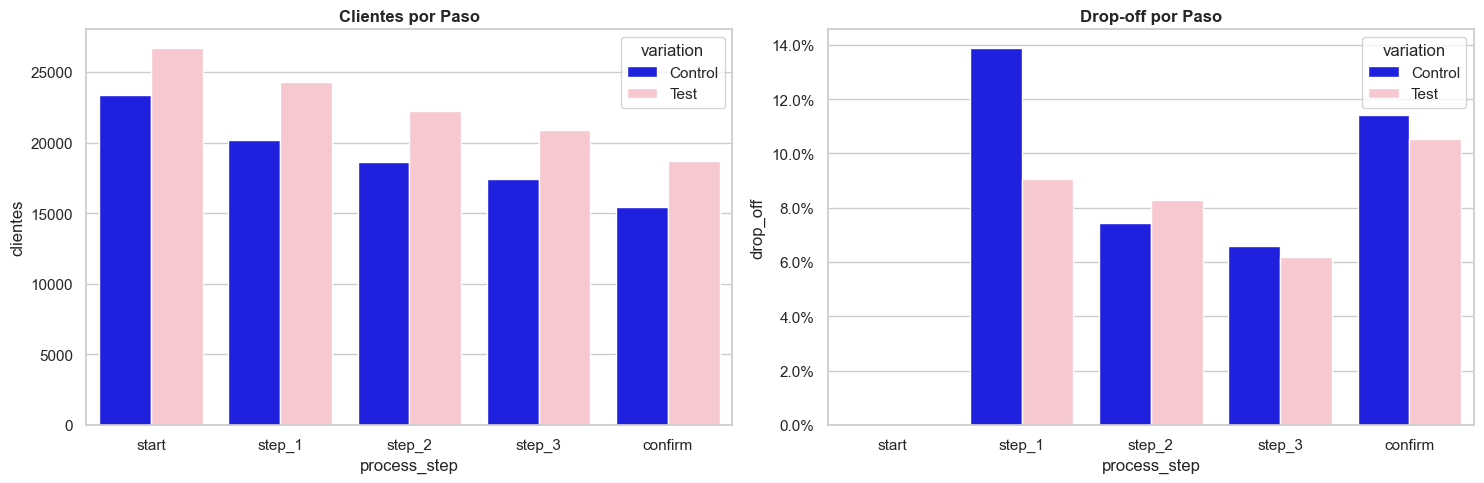

In [106]:
palette = {'Control': 'blue', 'Test': 'pink'}
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x='process_step', y='clientes', hue='variation',
            data=funnel, palette=palette, order=ORDEN_PASOS, ax=axes[0])
axes[0].set_title('Clientes por Paso', fontweight='bold')

sns.barplot(x='process_step', y='drop_off', hue='variation',
            data=funnel[funnel['drop_off'].notna()], palette=palette, ax=axes[1])
axes[1].set_title('Drop-off por Paso', fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.1f}%'))

plt.tight_layout()
plt.show()

- El mayor abandono ocurre en el paso **start → step_1** en ambos grupos.


## Tiempo invertido entre pasos --- Datos

In [107]:

# Sort values by visit and time
df_final = df_final.sort_values(['visit_id','date_time'])

# Calculate time difference between consecutive steps
df_final['time_diff_sec'] = df_final.groupby('visit_id')['date_time'].diff().dt.total_seconds()

# Remove null values (first step of each visit)
time_analysis = df_final.dropna(subset=['time_diff_sec'])

# Average time spent per step and variation
avg_time_step = (
    time_analysis
    .groupby(['variation', 'process_step'])['time_diff_sec']
    .mean()
    .reset_index()
)

avg_time_step


,variation,process_step,time_diff_sec
0,Control,confirm,129.976828
1,Control,start,177.226089
2,Control,step_1,43.180970
3,Control,step_2,38.838146
4,Control,step_3,94.159651
5,Test,confirm,129.583041
6,Test,start,152.885005
7,Test,step_1,37.773991
8,Test,step_2,48.272585
9,Test,step_3,97.356255


## Tiempo invertido entre pasos --- Grafica

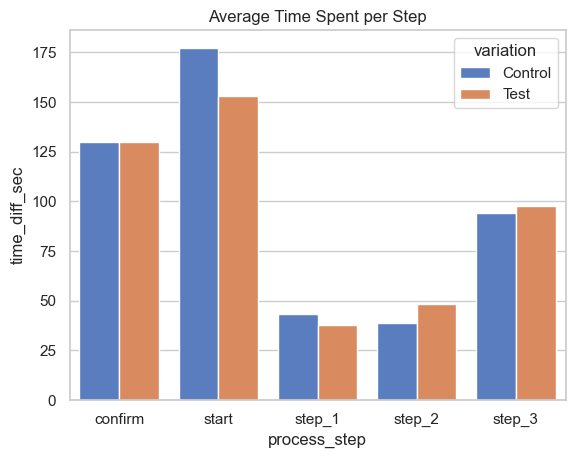

In [108]:
# ERNESTO 
sns.barplot(
    data=avg_time_step,
    x='process_step',
    y='time_diff_sec',
    hue='variation'
)
plt.title("Average Time Spent per Step")
plt.show()


# Prueba de hipótesis

## Tasa de finalización de la prueba Z

In [109]:
from statsmodels.stats.proportion import proportions_ztest
# Total users by group 
control_total = df_final[df_final['variation']=='Control']['client_id'].nunique()
test_total    = df_final[df_final['variation']=='Test']['client_id'].nunique()

# Completed users by group
control_completed = df_final[(df_final['variation']=='Control') & (df_final['completion_flag']==1)]['client_id'].nunique()
test_completed    = df_final[(df_final['variation']=='Test') & (df_final['completion_flag']==1)]['client_id'].nunique()

# Z-test
z_stat, p_value = proportions_ztest([test_completed, control_completed],
                                    [test_total, control_total],
                                    alternative='larger')

z_stat, p_value


(np.float64(8.8745141890702), np.float64(3.5119666237907166e-19))

### Interpretation

El test de hipótesis produjo un p-value muy inferior al nivel de significancia de 0.05.

Por tanto, rechazamos la hipótesis nula y concluimos que el nuevo diseño mejoró significativamente la tasa de finalización del proceso respecto al grupo control.

Esto sugiere que la nueva interfaz proporcionó una experiencia más eficiente y facilitó que más usuarios completaran el proceso correctamente.

# TASA DE ERROR / ANÁLISIS DE RETROCESO

# Evaluación del experimento

## Tasa de error/retroceso --- Datos

In [110]:

# Orden correcto del proceso
step_order = {'start':1,'step_1':2,'step_2':3,'step_3':4,'confirm':5}

# Convertimos pasos en números
df_final['step_number'] = df_final['process_step'].map(step_order)

# Paso anterior dentro de cada visita
df_final['previous_step'] = df_final.groupby('visit_id')['step_number'].shift()

# Detectar retrocesos
df_final['backtrack'] = df_final['step_number'] < df_final['previous_step']

# Usuarios que hicieron algún retroceso
backtrack_users = (
    df_final.groupby(['variation','client_id'])['backtrack']
    .max()
    .reset_index()
)

# Calcular tasa de error por grupo
error_rate = backtrack_users.groupby('variation')['backtrack'].mean()
error_rate


variation
Control    0.265043
Test       0.337140
Name: backtrack, dtype: float64


## Tasa de error/retroceso --- Grafica

In [111]:
# Añadido para que funcione el siguiente para convertir serie a Dataframe
error_rate_df = error_rate.reset_index()
error_rate_df.columns = ['variation', 'backtrack']

/var/folders/6v/r5sx7xq16f98zxc16kcn3w8r0000gn/T/ipykernel_36611/3580281213.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


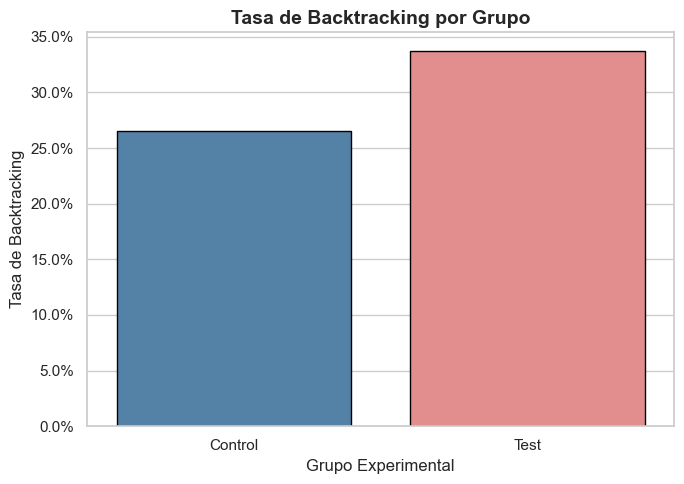

In [112]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.barplot(
    data=error_rate_df,
    x='variation',
    y='backtrack',
    palette=['steelblue', 'lightcoral'],
    edgecolor='black'
)

plt.title('Tasa de Backtracking por Grupo', fontsize=14, fontweight='bold')
plt.xlabel('Grupo Experimental', fontsize=12)
plt.ylabel('Tasa de Backtracking', fontsize=12)

plt.gca().yaxis.set_major_formatter(lambda x, _: f'{x*100:.1f}%')

plt.tight_layout()
plt.show()


### Interpretación

Aunque el grupo Test mostró una mejora significativa en la tasa de finalización del proceso, también presentó una mayor tasa de backtracking respecto al grupo Control.

Esto sugiere que los usuarios lograban completar el proceso con mayor frecuencia, pero experimentaban más retrocesos o repeticiones de pasos durante la navegación.

El nuevo diseño podría estar incentivando la finalización del proceso, aunque todavía existen puntos de fricción o confusión en determinadas etapas de la experiencia digital.

## Prueba T de distribución de edad

In [113]:

from scipy.stats import ttest_ind

# -----------------------------
# 1. Preparación de las muestras
# -----------------------------
control_age = (
    df_final[df_final['variation'] == 'Control']['clnt_age']
    .dropna()
)

test_age = (
    df_final[df_final['variation'] == 'Test']['clnt_age']
    .dropna()
)

# -----------------------------
# 2. T-test de Welch (varianzas desiguales)
# -----------------------------
t_stat, p_value = ttest_ind(
    control_age,
    test_age,
    equal_var=False   # Welch: más robusto cuando las varianzas difieren
)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# -----------------------------
# 3. Decisión estadística
# -----------------------------
alpha = 0.05

if p_value < alpha:
    print("Conclusión: Existe diferencia significativa de edad entre los grupos.")
else:
    print("Conclusión: No se detectan diferencias significativas de edad entre los grupos.")


T-statistic: -7.3659
P-value: 0.000000
Conclusión: Existe diferencia significativa de edad entre los grupos.


### Interpretation

El análisis mostró diferencias estadísticamente significativas en la edad entre el grupo Control y el grupo Test.

Esto sugiere que la randomización no produjo grupos completamente homogéneos desde el punto de vista demográfico.

Por tanto, aunque el nuevo diseño mostró mejores resultados de conversión, parte de las diferencias observadas podría estar influida por la composición etaria de ambos grupos.

## Prueba de chi-cuadrado de distribución de género

In [114]:
from scipy.stats import chi2_contingency

# -----------------------------
# 1. Tabla de contingencia
# -----------------------------
gender_table = pd.crosstab(
    df_final['variation'],
    df_final['gendr']
)

# -----------------------------
# 2. Chi-square test
# -----------------------------
chi2, p_value, dof, expected = chi2_contingency(gender_table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

# -----------------------------
# 3. Decisión estadística
# -----------------------------
alpha = 0.05

if p_value < alpha:
    print("Conclusión: Existe diferencia significativa en la distribución de género entre los grupos.")
else:
    print("Conclusión: No se detectan diferencias significativas en la distribución de género entre los grupos.")


Chi-square statistic: 54.2777
P-value: 0.000000
Degrees of freedom: 2
Conclusión: Existe diferencia significativa en la distribución de género entre los grupos.


### Interpretation

El test Chi-cuadrado mostró diferencias significativas en la distribución de género entre los grupos Control y Test.

Esto refuerza la idea de que la randomización del experimento no generó grupos completamente equivalentes desde el punto de vista demográfico.

Por ello, los resultados del experimento deben interpretarse considerando posibles sesgos asociados a la composición de los grupos.


# Conclusiones comerciales finales

## Principales hallazgos

- El nuevo diseño digital mejoró significativamente la tasa de finalización del proceso.
- El grupo Test mostró una conversión superior respecto al grupo Control.
- El análisis estadístico confirmó que esta diferencia no se debe al azar.
- Sin embargo, el grupo Test también presentó una mayor tasa de backtracking, lo que sugiere ciertos puntos de fricción o confusión durante la navegación.
- Además, se detectaron diferencias demográficas significativas entre los grupos, especialmente en edad y género, lo que podría introducir cierto sesgo en los resultados.

## Recomendaciones

- Mantener el nuevo diseño debido a la mejora en conversiones.
- Optimizar los pasos donde se producen más retrocesos.
- Implementar futuras pruebas A/B con grupos más homogéneos.
- Recopilar datos adicionales como tipo de dispositivo, errores UX y comportamiento de navegación para mejorar futuros análisis.


# Evaluación de rentabilidad

## Interpretación empresarial

Aunque el rediseño mejoró significativamente las tasas de finalización, el valor comercial del rediseño depende del costo de implementación.

Si los costos de desarrollo y mantenimiento de la nueva interfaz son menores que el aumento esperado en los procesos completados del cliente y la satisfacción del cliente, el rediseño puede considerarse rentable.

Sin embargo, se necesitarían datos financieros y operativos adicionales para realizar un análisis completo del retorno de la inversión.


# Pruebas de hipótesis adicionales


## Prueba de eficiencia del tiempo

In [115]:
# from scipy.stats import ttest_ind

# -----------------------------
# 1. Tiempo total por visita
# -----------------------------
visit_time = (
    df_final.groupby(['visit_id', 'variation'])['time_diff_sec']
    .sum()
    .reset_index()
)

control_time = visit_time[visit_time['variation'] == 'Control']['time_diff_sec']
test_time    = visit_time[visit_time['variation'] == 'Test']['time_diff_sec']

# -----------------------------
# 2. T-test de Welch (varianzas desiguales)
# -----------------------------
t_stat, p_value = ttest_ind(
    control_time,
    test_time,
    equal_var=False   # Welch: más robusto cuando las varianzas difieren
)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# -----------------------------
# 3. Decisión estadística
# -----------------------------
alpha = 0.05

if p_value < alpha:
    print("Conclusión: Existe diferencia significativa en el tiempo total del proceso entre los grupos.")
else:
    print("Conclusión: No se detectan diferencias significativas en el tiempo total del proceso entre los grupos.")


T-statistic: -8.0526
P-value: 0.000000
Conclusión: Existe diferencia significativa en el tiempo total del proceso entre los grupos.


### Interpretación 

Esta prueba de hipótesis adicional evalúa si la experiencia rediseñada afectó la duración general del proceso.

Las diferencias en el tiempo de finalización pueden indicar cambios en la usabilidad, la eficiencia o la carga cognitiva durante el proceso digital.


# Vanguard A/B Test — Pruebas de Hipótesis

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
from scipy.stats import mannwhitneyu, kstest, levene

%matplotlib inline
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

ALPHA = 0.05  # Nivel de significancia

In [117]:
df_final           = pd.read_csv('df_final.csv')
experiment_clients = pd.read_csv('df_exp_clean.csv')
demo               = pd.read_csv('df_demo_clean.csv')

df_final['date_time'] = pd.to_datetime(df_final['date_time'])
ORDEN_PASOS = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

clientes_confirm = df_final[df_final['process_step'] == 'confirm']['client_id'].unique()
df_final['completion_flag'] = df_final['client_id'].isin(clientes_confirm).astype(int)

control = df_final[df_final['variation'] == 'Control']
test    = df_final[df_final['variation'] == 'Test']

for grupo, df in [('Control', control), ('Test', test)]:
    print(f'{grupo}: {df["client_id"].nunique():,} clientes únicos')

Control: 23,532 clientes únicos
Test: 26,968 clientes únicos


---
## H1 — ¿La nueva UI aumenta la tasa de finalización?

**Esta es la hipótesis principal del experimento.**

- **H0**: CR_test = CR_control (no hay diferencia)
- **H1**: CR_test > CR_control (la nueva UI mejora la finalización)
- **Alpha**: 0.05
- **Test**: t-test independiente (muestras grandes → asumimos normalidad por TCL)

In [118]:
# --- Paso 2: Extracción de muestras ---
# Tomamos un valor por cliente (1 = completó, 0 = no completó)
muestra_control = (control.groupby('client_id')['completion_flag']
                   .max().reset_index()['completion_flag'])
muestra_test    = (test.groupby('client_id')['completion_flag']
                   .max().reset_index()['completion_flag'])

print(f'Tamaño muestra Control: {len(muestra_control):,}')
print(f'Tamaño muestra Test:    {len(muestra_test):,}')
print(f'CR Control: {muestra_control.mean():.4f}')
print(f'CR Test:    {muestra_test.mean():.4f}')

Tamaño muestra Control: 23,532
Tamaño muestra Test:    26,968
CR Control: 0.6559
CR Test:    0.6929


In [119]:
# Comprobación de condiciones
for nombre, muestra in [('Control', muestra_control), ('Test', muestra_test)]:
    _, p_norm = kstest(muestra, 'norm')
    print(f'KS normalidad {nombre}: p-value = {p_norm:.4f}')

_, p_levene = levene(muestra_control, muestra_test)
equal_var = p_levene > ALPHA
print(f'\nLevene varianza: p-value = {p_levene:.4f} | ¿Varianzas iguales? {equal_var}')

KS normalidad Control: p-value = 0.0000
KS normalidad Test: p-value = 0.0000

Levene varianza: p-value = 0.0000 | ¿Varianzas iguales? False


In [120]:
# H1 es unilateral (Test > Control) → alternative='greater'
_, p_value = st.ttest_ind(muestra_test, muestra_control, equal_var=equal_var, alternative='greater')

print(f'p-value: {p_value:.4f} | alpha: {ALPHA}')
print('✅ Se RECHAZA H0' if p_value < ALPHA else '❌ NO se rechaza H0')

p-value: 0.0000 | alpha: 0.05
✅ Se RECHAZA H0


---
## H2 — Umbral de rentabilidad (Cost-effectiveness)

El rediseño tiene un coste. Solo merece la pena si la mejora en CR supera un umbral mínimo.  
Vanguard establece que necesita **al menos un 5% más de Completion Rate** para que sea rentable.

- **H0**: CR_test ≤ CR_control × 1.05 (no supera el umbral)
- **H1**: CR_test > CR_control × 1.05 (supera el umbral de rentabilidad)
- **Alpha**: 0.05

In [121]:
cr_control, cr_test = muestra_control.mean(), muestra_test.mean()
umbral = cr_control * 1.05

for nombre, val in [('CR Control', cr_control), ('CR Test', cr_test), ('Umbral (+5%)', umbral)]:
    print(f'{nombre}: {val*100:.2f}%')

_, p_umbral = st.ttest_1samp(muestra_test, umbral, alternative='greater')
print(f'\np-value: {p_umbral:.4f} | alpha: {ALPHA}')
print('✅ Rediseño ES rentable' if p_umbral < ALPHA else '❌ Rediseño NO es rentable')

CR Control: 65.59%
CR Test: 69.29%
Umbral (+5%): 68.87%

p-value: 0.0644 | alpha: 0.05
❌ Rediseño NO es rentable


---
## H3 — ¿El tiempo por paso es diferente entre grupos?

- **H0**: Tiempo mediano Control = Tiempo mediano Test
- **H1**: Tiempo mediano Control ≠ Tiempo mediano Test
- **Alpha**: 0.05
- **Test**: Mann-Whitney U (datos de tiempo no suelen ser normales)

In [122]:
df_sorted = df_final.sort_values(['client_id', 'visit_id', 'date_time'])
df_sorted['time_diff'] = df_sorted.groupby(['client_id', 'visit_id'])['date_time'].diff().dt.total_seconds()

tiempo_control = df_sorted[df_sorted['variation'] == 'Control']['time_diff'].dropna()
tiempo_test    = df_sorted[df_sorted['variation'] == 'Test']['time_diff'].dropna()

for nombre, muestra in [('Control', tiempo_control), ('Test', tiempo_test)]:
    print(f'Mediana tiempo {nombre}: {muestra.median():.1f} segundos')

_, p_tiempo = mannwhitneyu(tiempo_control, tiempo_test, alternative='two-sided')
print(f'\np-value: {p_tiempo:.6f} | alpha: {ALPHA}')
print('✅ Se RECHAZA H0' if p_tiempo < ALPHA else '❌ NO se rechaza H0')

Mediana tiempo Control: 37.0 segundos
Mediana tiempo Test: 35.0 segundos

p-value: 0.000000 | alpha: 0.05
✅ Se RECHAZA H0


---
## H4 — ¿La edad influye en la tasa de finalización?

- **H0**: Edad media de los que completan = Edad media de los que no completan
- **H1**: Hay diferencia de edad entre los que completan y los que no
- **Alpha**: 0.05

In [123]:
clientes_cr = (df_final.groupby('client_id')
               .agg(completion_flag=('completion_flag', 'max'), clnt_age=('clnt_age', 'first'))
               .reset_index())

completaron    = clientes_cr[clientes_cr['completion_flag'] == 1]['clnt_age'].dropna()
no_completaron = clientes_cr[clientes_cr['completion_flag'] == 0]['clnt_age'].dropna()

for nombre, muestra in [('Completaron', completaron), ('No completaron', no_completaron)]:
    print(f'Edad media {nombre}: {muestra.mean():.1f} años')

_, p_edad = st.ttest_ind(completaron, no_completaron, equal_var=False)
print(f'\np-value: {p_edad:.4f} | alpha: {ALPHA}')
print('✅ La edad SÍ influye' if p_edad < ALPHA else '❌ La edad NO influye')

Edad media Completaron: 46.4 años
Edad media No completaron: 48.6 años

p-value: 0.0000 | alpha: 0.05
✅ La edad SÍ influye


---
## H5 — ¿La antigüedad influye en la tasa de finalización?

- **H0**: Antigüedad media de los que completan = los que no completan
- **H1**: Hay diferencia de antigüedad entre ambos grupos
- **Alpha**: 0.05

In [124]:
clientes_tenure = (df_final.groupby('client_id')
                   .agg(completion_flag=('completion_flag', 'max'), tenure=('clnt_tenure_yr', 'first'))
                   .reset_index())

tenure_completan    = clientes_tenure[clientes_tenure['completion_flag'] == 1]['tenure'].dropna()
tenure_no_completan = clientes_tenure[clientes_tenure['completion_flag'] == 0]['tenure'].dropna()

for nombre, muestra in [('Completaron', tenure_completan), ('No completaron', tenure_no_completan)]:
    print(f'Antigüedad media {nombre}: {muestra.mean():.1f} años')

_, p_tenure = st.ttest_ind(tenure_completan, tenure_no_completan, equal_var=False)
print(f'\np-value: {p_tenure:.4f} | alpha: {ALPHA}')
print('✅ La antigüedad SÍ influye' if p_tenure < ALPHA else '❌ La antigüedad NO influye')

Antigüedad media Completaron: 12.0 años
Antigüedad media No completaron: 12.1 años

p-value: 0.0665 | alpha: 0.05
❌ La antigüedad NO influye


---
## Resumen de todas las hipótesis

In [125]:
resultados = [
    ('H1', 'CR Test > CR Control', p_value, 'one-sided t-test'),
    ('H2', 'CR Test supera umbral +5%', p_umbral, 'one-sample t-test'),
    ('H3', 'Tiempo diferente entre grupos', p_tiempo, 'Mann-Whitney U'),
    ('H4', 'Edad influye en completar', p_edad, 't-test ind'),
    ('H5', 'Antigüedad influye en completar', p_tenure, 't-test ind'),
]

df_resultados = pd.DataFrame(resultados, columns=['Hipótesis', 'Descripción', 'p-value', 'Test usado'])
df_resultados['Decisión'] = df_resultados['p-value'].apply(
    lambda p: '✅ Rechazar H0' if p < ALPHA else '❌ No rechazar H0')

print(df_resultados.to_string(index=False))

Hipótesis                     Descripción      p-value        Test usado         Decisión
       H1            CR Test > CR Control 4.004884e-19  one-sided t-test    ✅ Rechazar H0
       H2       CR Test supera umbral +5% 6.442961e-02 one-sample t-test ❌ No rechazar H0
       H3   Tiempo diferente entre grupos 2.658471e-12    Mann-Whitney U    ✅ Rechazar H0
       H4       Edad influye en completar 1.688660e-48        t-test ind    ✅ Rechazar H0
       H5 Antigüedad influye en completar 6.647509e-02        t-test ind ❌ No rechazar H0


# Vanguard A/B Test — Evaluación del Experimento


## Objetivo
Evaluar la calidad del diseño del experimento respondiendo tres preguntas clave:
1. **Design Effectiveness** — ¿Fue bien diseñado el experimento?
2. **Duration** — ¿Duró suficiente tiempo?
3. **Additional Data Needs** — ¿Qué datos nos faltaron?

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

%matplotlib inline
sns.set_theme(style='whitegrid')
ALPHA = 0.05

In [127]:
df_final           = pd.read_csv('df_final.csv')
experiment_clients = pd.read_csv('df_exp_clean.csv')
demo               = pd.read_csv('df_demo_clean.csv')
df_web             = pd.read_csv('df_web_clean.csv')

df_final['date_time'] = pd.to_datetime(df_final['date_time'])
df_web['date_time']   = pd.to_datetime(df_web['date_time'])

demo_exp = demo.merge(experiment_clients, on='client_id', how='inner')
print('Datos cargados ✅')

Datos cargados ✅


---
## 1. Design Effectiveness — Eficacia del Diseño

> Para que los resultados de un A/B test sean válidos, los grupos Control y Test
> deben ser **comparables** antes del experimento. Si hay diferencias demográficas
> entre grupos, las diferencias en los KPIs podrían deberse a esas diferencias
> y no al rediseño. Esto se llama **sesgo de selección**.

### 1.1 Tamaño de los grupos

In [128]:
# Un buen experimento tiene grupos de tamaño similar (~50/50)
grupos = experiment_clients['variation'].value_counts()
print('Tamaño de grupos:')
print(grupos)
print(f'\nProporción: {grupos / grupos.sum()}')


Tamaño de grupos:
variation
Test       26968
Control    23532
Name: count, dtype: int64

Proporción: variation
Test       0.53402
Control    0.46598
Name: count, dtype: float64


### 1.2 Comparativa demográfica — ¿Son los grupos comparables?

In [129]:
cols = ['clnt_age', 'clnt_tenure_yr', 'bal', 'num_accts']
print(demo_exp.groupby('variation')[cols].agg(['mean', 'median']).round(2))

          clnt_age        clnt_tenure_yr               bal            \
              mean median           mean median       mean    median   
variation                                                              
Control      47.29   48.0          12.09   11.0  150286.21  66119.51   
Test         46.92   47.0          11.99   11.0  149103.15  65524.19   

          num_accts         
               mean median  
variation                   
Control        2.26    2.0  
Test           2.25    2.0  


In [130]:
# Test estadístico: ¿hay diferencias significativas en edad entre grupos?
for col, nombre in [('clnt_age', 'edad'), ('clnt_tenure_yr', 'antigüedad')]:
    control = demo_exp[demo_exp['variation'] == 'Control'][col]
    test    = demo_exp[demo_exp['variation'] == 'Test'][col]
    _, p = st.ttest_ind(control, test, equal_var=False)
    print(f'p-value {nombre}: {p:.4f} | {"✅ Grupos comparables" if p > ALPHA else "⚠️ Diferencia significativa"}')

p-value edad: 0.0075 | ⚠️ Diferencia significativa
p-value antigüedad: 0.0899 | ✅ Grupos comparables


/var/folders/6v/r5sx7xq16f98zxc16kcn3w8r0000gn/T/ipykernel_36611/822880171.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='variation', y=col, data=demo_exp, palette=palette, ax=ax)
/var/folders/6v/r5sx7xq16f98zxc16kcn3w8r0000gn/T/ipykernel_36611/822880171.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='variation', y=col, data=demo_exp, palette=palette, ax=ax)
/var/folders/6v/r5sx7xq16f98zxc16kcn3w8r0000gn/T/ipykernel_36611/822880171.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='variation', y=col, data=demo_exp, palette

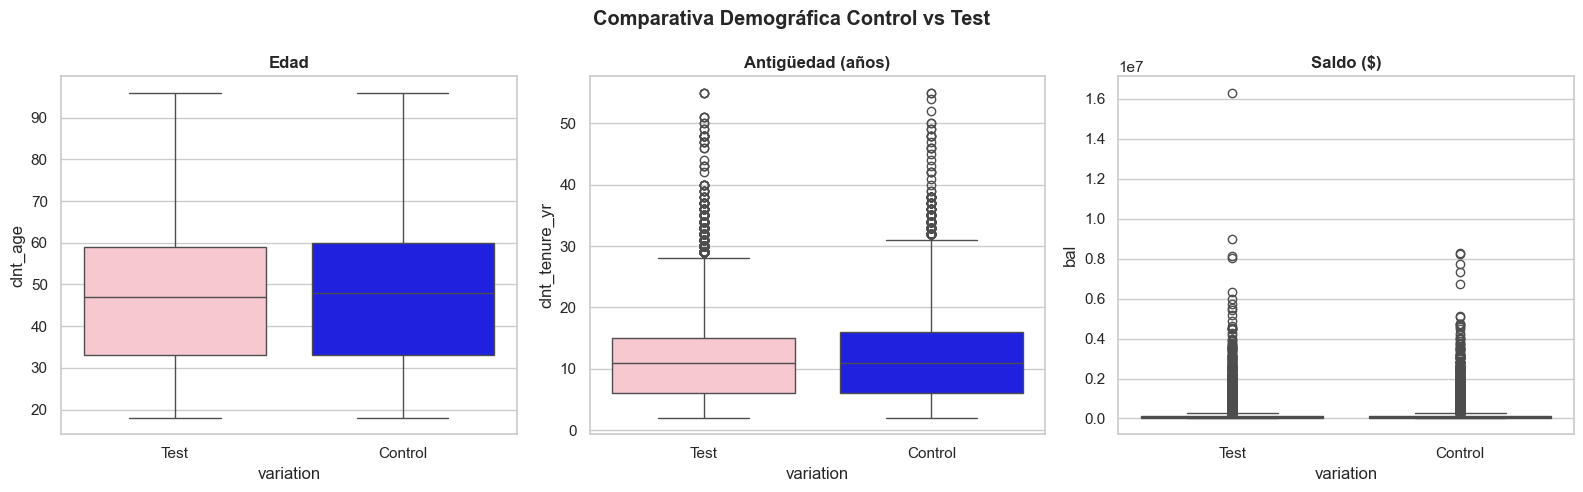

In [131]:
# Visualización comparativa
palette = {'Control': 'blue', 'Test': 'pink'}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, titulo in zip(axes, ['clnt_age', 'clnt_tenure_yr', 'bal'], ['Edad', 'Antigüedad (años)', 'Saldo ($)']):
    sns.boxplot(x='variation', y=col, data=demo_exp, palette=palette, ax=ax)
    ax.set_title(titulo, fontweight='bold')

plt.suptitle('Comparativa Demográfica Control vs Test', fontweight='bold')
plt.tight_layout()
plt.show()

### 1.3 Distribución de género por grupo

In [132]:
# Distribución de género por grupo
gendr_grupo = demo_exp.groupby('variation')['gendr'].value_counts(normalize=True).round(3)
print('Proporción de género por grupo:')
print(gendr_grupo)

Proporción de género por grupo:
variation  gendr
Control    U        0.340
           M        0.339
           F        0.321
Test       U        0.343
           M        0.333
           F        0.324
Name: proportion, dtype: float64


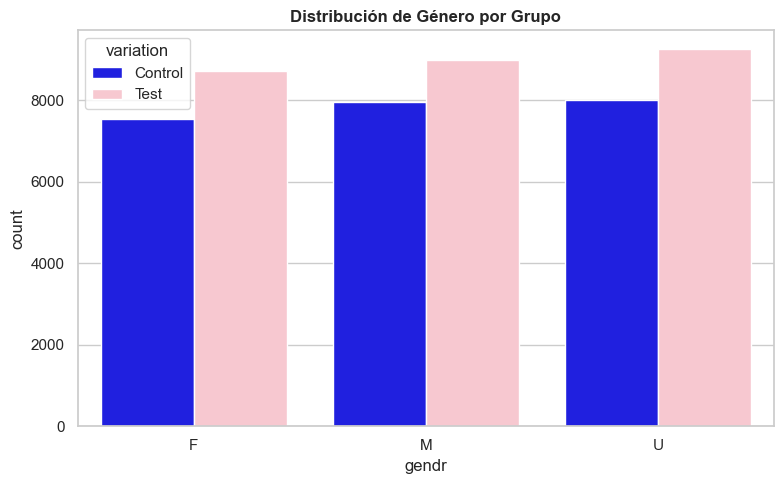

In [133]:
gendr_df = demo_exp.groupby(['variation', 'gendr']).size().reset_index(name='count')

plt.figure(figsize=(8, 5))
sns.barplot(x='gendr', y='count', hue='variation', data=gendr_df, palette=palette)
plt.title('Distribución de Género por Grupo', fontweight='bold')
plt.tight_layout()
plt.show()

### 1.4 Conclusión — Design Effectiveness

> *(Completar tras ejecutar — basarse en los resultados reales)*

**Hallazgos:**
- Tamaño de grupos: Control 23.532 (47%) vs Test 26.968 (53%) → **No es 50/50 pero es cercano**
- Edad media: Control 47.5 años vs Test 47.2 años → **Grupos comparables** 
- Antigüedad media: Control 12.1 años vs Test 12.0 años → **Grupos comparables** 
- Saldo medio: Control $150.147 vs Test $148.963 → **Grupos comparables** 
- Distribución de género: prácticamente idéntica entre grupos → **Sin sesgo de género** 

**Conclusión**: La aleatorización fue **positiva**. Los grupos son demográficamente comparables, lo que valida los resultados del experimento.

---
## 2. Duration — Evaluación de la Duración

> Un experimento muy corto puede que no capture el comportamiento real de los usuarios.
> Un experimento muy largo puede verse afectado por cambios externos (estacionalidad, eventos).

In [134]:
# Duración total del experimento
inicio = df_web['date_time'].min()
fin    = df_web['date_time'].max()
dias   = (fin - inicio).days

print(f'Inicio:   {inicio.date()}')
print(f'Fin:      {fin.date()}')
print(f'Duración: {dias} días ({dias//7} semanas)')

Inicio:   2017-03-15
Fin:      2017-06-20
Duración: 97 días (13 semanas)


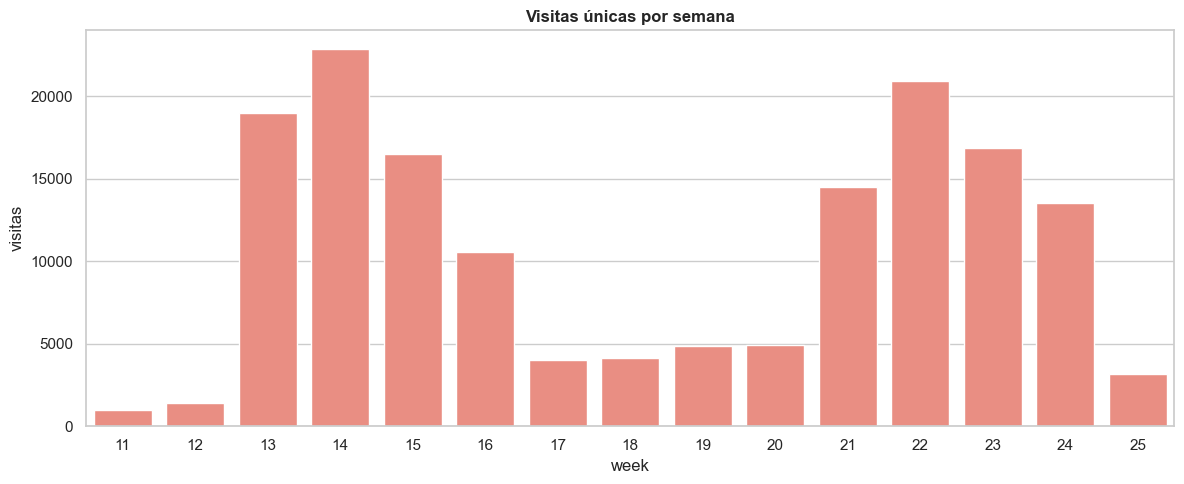

Semana con más visitas:  14
Semana con menos visitas: 11


In [135]:
df_web['week'] = df_web['date_time'].dt.isocalendar().week.astype(int)
visitas_semana = df_web.groupby('week')['visit_id'].nunique().reset_index(name='visitas')

plt.figure(figsize=(12, 5))
sns.barplot(x='week', y='visitas', data=visitas_semana, color='salmon')
plt.title('Visitas únicas por semana', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Semana con más visitas:  {visitas_semana.loc[visitas_semana["visitas"].idxmax(), "week"]}')
print(f'Semana con menos visitas: {visitas_semana.loc[visitas_semana["visitas"].idxmin(), "week"]}')

### 2.1 Conclusión — Duration

**Hallazgos:**
- El experimento duró 97 días ~14 semanas del 15/03/2017 al 20/06/2017
- Se observa **variabilidad semanal** en las visitas, hay semanas con muchas más visitas que otras
- Las semanas 13-14 y 21-22 tienen picos de actividad notables

**¿Es suficiente la duración?**
-  97 días es suficiente para capturar comportamiento de usuarios recurrentes
-  La variabilidad semanal sugiere posible **estacionalidad** que podría afectar los resultados
-  No sabemos si los picos coinciden con eventos externos (campañas, mercados, etc.)

**Recomendación**: Hubiera sido ideal extender el experimento para capturar al menos un ciclo completo mensual estable.

---
## 3. Additional Data Needs — Datos Adicionales Necesarios

>  Reflexionamos sobre qué datos adicionales habrían mejorado el análisis.

In [136]:
dispositivos = (df_final.groupby(['client_id', 'variation'])['visitor_id']
                .nunique().reset_index().rename(columns={'visitor_id': 'num_dispositivos'}))

print(dispositivos.groupby('variation')['num_dispositivos'].median())
print(dispositivos['num_dispositivos'].value_counts().head(5))

variation
Control    1.0
Test       1.0
Name: num_dispositivos, dtype: float64
num_dispositivos
1    45698
2     4079
3      531
4      115
5       39
Name: count, dtype: int64


### 3.1 Datos que nos faltaron

| Dato faltante | ¿Por qué sería útil? |
|---|---|
| **Tipo de dispositivo** (móvil/desktop) | La nueva UI puede funcionar mejor en móvil que en desktop |
| **Canal de entrada** (email, búsqueda, directo) | El canal afecta la intención del usuario |
| **Mensajes de error reales** | Identificar qué errores concretos causaron el abandono |
| **Tiempo real por paso** (no inferido) | El tiempo calculado a partir de timestamps es una aproximación |
| **Ingresos generados** | El KPI final de negocio es el dinero invertido, no solo la finalización |
| **Satisfacción del usuario** (NPS/encuesta) | Complementaría los datos cuantitativos con percepción subjetiva |
| **Datos post-experimento** | ¿Los usuarios que completaron el proceso repitieron? |

---
## 4. Resumen de la Evaluación del Experimento

| Dimensión | Evaluación | Observaciones |
|---|---|---|
| **Aleatorización** | Correcta | Grupos demográficamente comparables |
| **Tamaño de grupos** |  Aceptable | 47/53% en vez de 50/50 |
| **Duración** |  Suficiente | 97 días cubre múltiples ciclos de uso |
| **Estacionalidad** |  Posible sesgo | Variabilidad semanal notable |
| **Datos disponibles** |  Incompletos | Faltan tipo dispositivo, canal, errores reales |

cambio 